In [ ]:
import zipfile
import os

zip_file_path = '/content/Vehicle dataset.zip'
extraction_path = '/content/vehicle_data'

# Create extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' extracted to '{extraction_path}'")

'/content/Vehicle dataset.zip' extracted to '/content/vehicle_data'


In [ ]:
# List the contents of the extracted directory
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extraction_path):
    for file in files:
        print(os.path.join(root, file))

Contents of the extracted directory:
/content/vehicle_data/CAR DETAILS FROM CAR DEKHO.csv
/content/vehicle_data/car details v4.csv
/content/vehicle_data/Car details v3.csv
/content/vehicle_data/car data.csv


In [ ]:
import pandas as pd

file_path = os.path.join(extraction_path, 'CAR DETAILS FROM CAR DEKHO.csv')
df = pd.read_csv(file_path)
display(df.head())

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [ ]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [ ]:
print('\nDescriptive Statistics:')
display(df.describe())


Descriptive Statistics:


,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


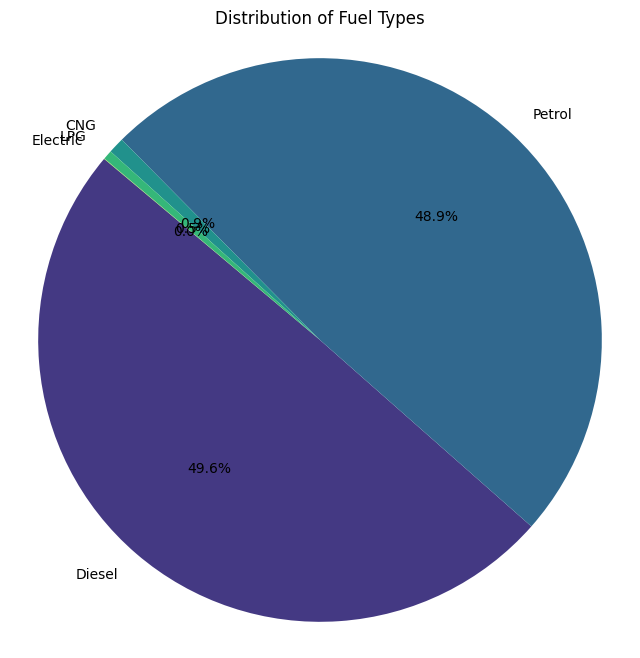

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each fuel type
fuel_counts = df['fuel'].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))
plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(fuel_counts)))
plt.title('Distribution of Fuel Types')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

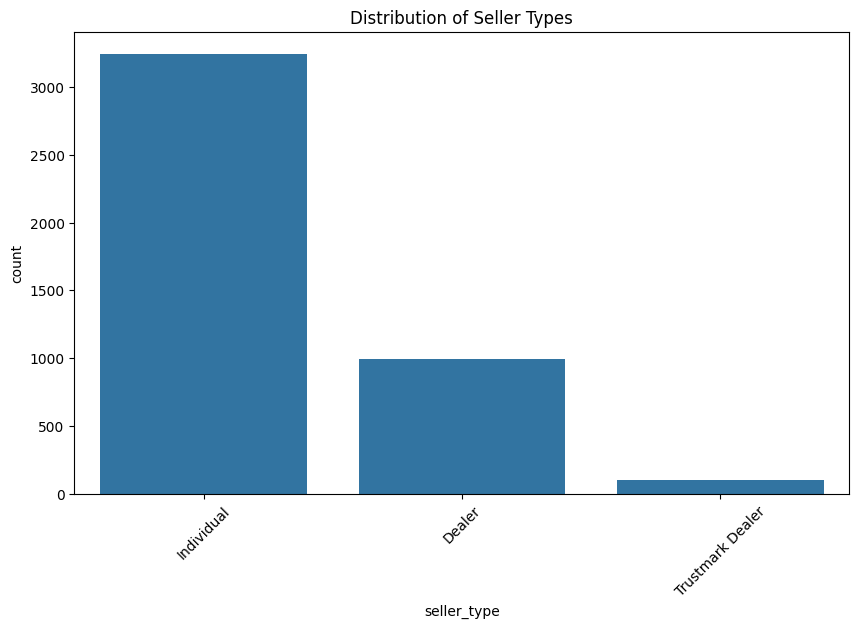

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(x="seller_type", data=df, order=df["seller_type"].value_counts().index)
plt.title("Distribution of Seller Types")
plt.xticks(rotation=45)
plt.show()

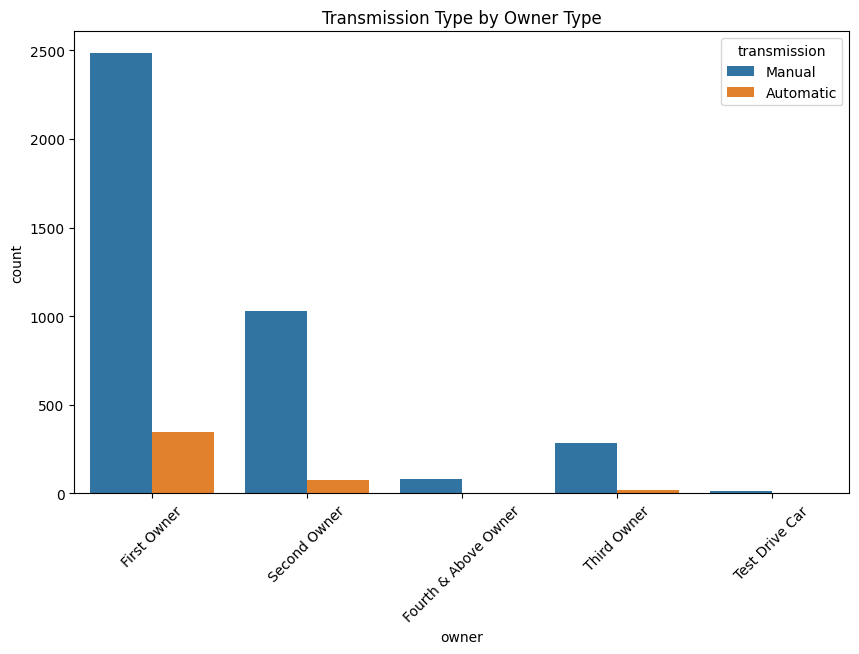

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x="owner", hue="transmission", data=df)
plt.title("Transmission Type by Owner Type")
plt.xticks(rotation=45)
plt.show()

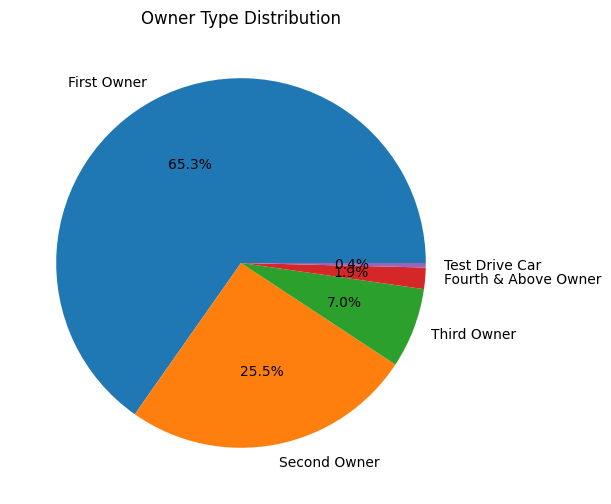

In [ ]:
owner_counts = df["owner"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(owner_counts, labels=owner_counts.index, autopct="%1.1f%%")
plt.title("Owner Type Distribution")
plt.show()

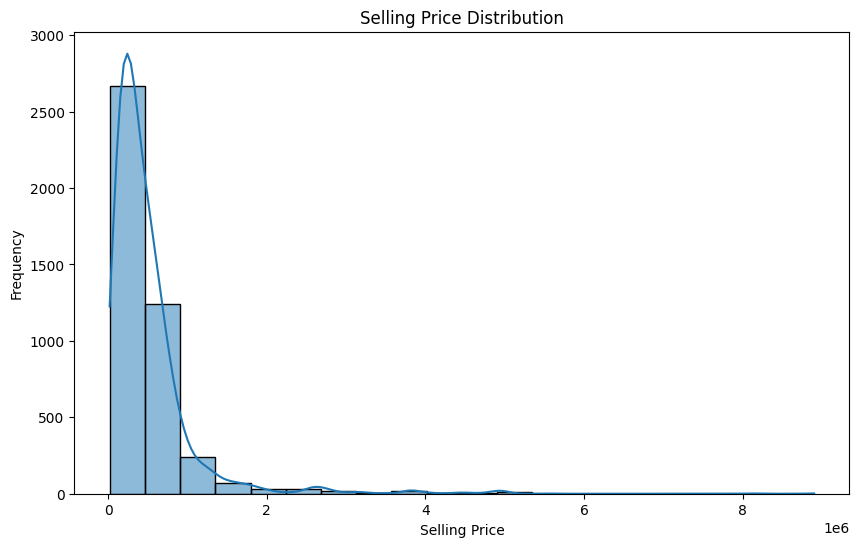

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df["selling_price"], bins=20, kde=True)
plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

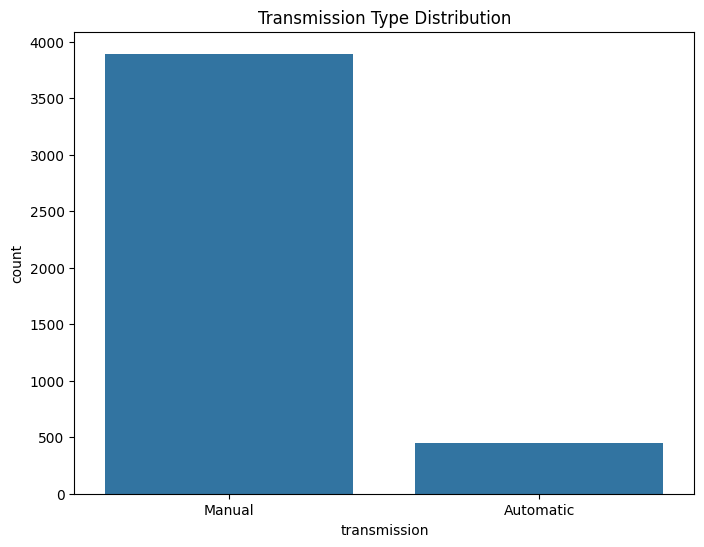

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x="transmission", data=df)
plt.title("Transmission Type Distribution")
plt.show()

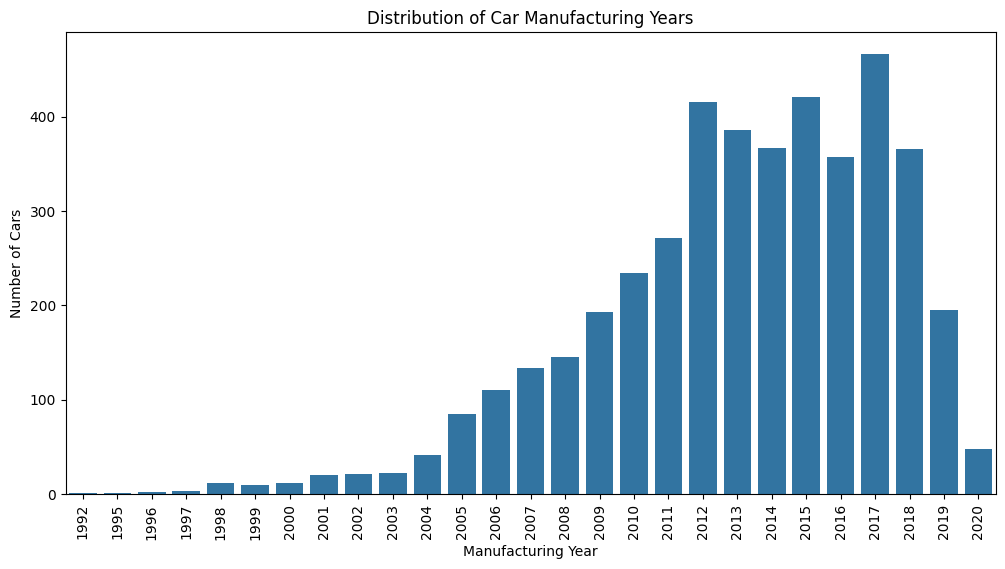

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x="year", data=df, order=df["year"].value_counts().index.sort_values())
plt.title("Distribution of Car Manufacturing Years")
plt.xlabel("Manufacturing Year")
plt.ylabel("Number of Cars")
plt.xticks(rotation=90)
plt.show()

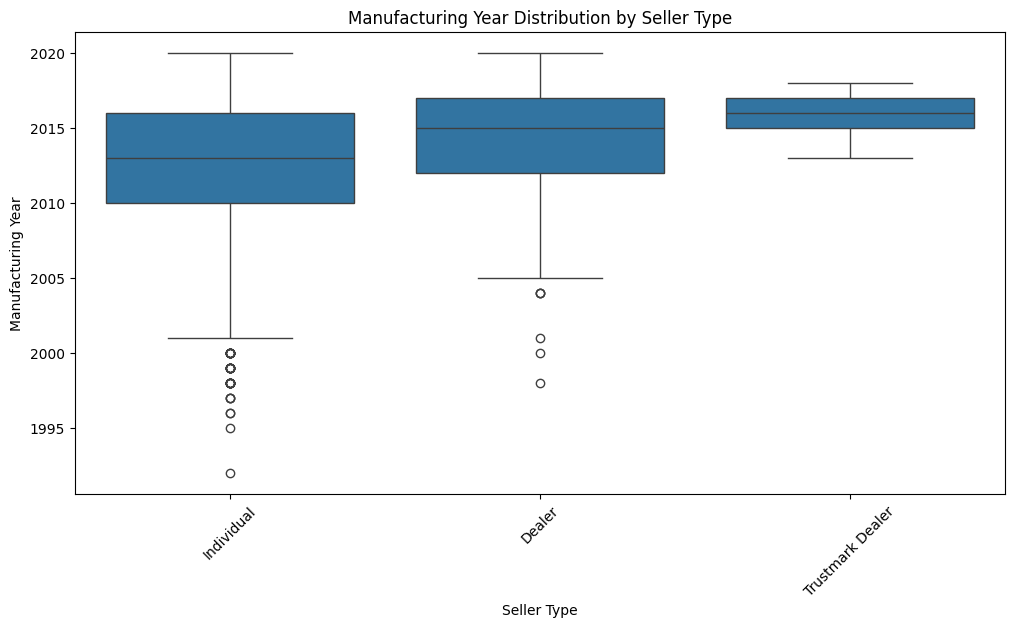

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x="seller_type", y="year", data=df)
plt.title("Manufacturing Year Distribution by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Manufacturing Year")
plt.xticks(rotation=45)
plt.show()

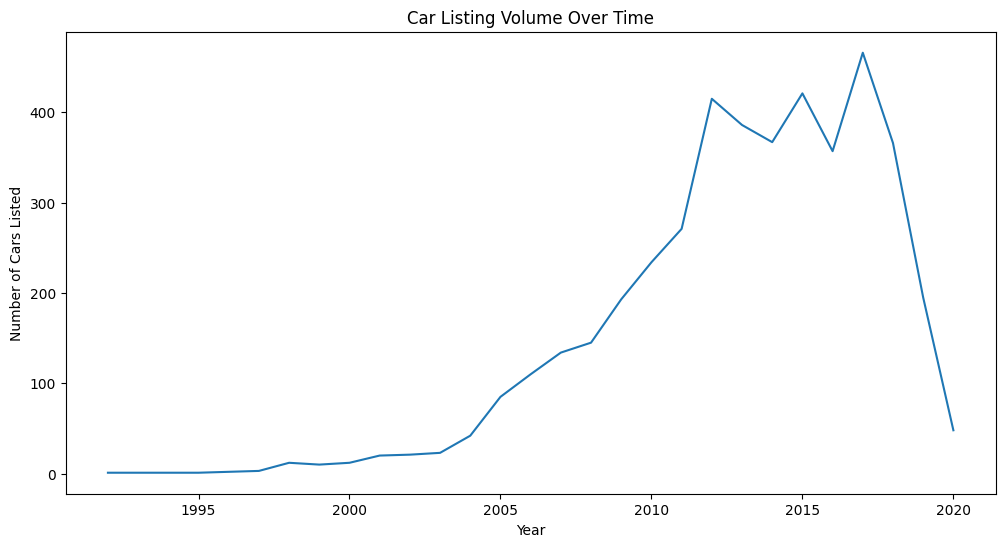

In [ ]:
plt.figure(figsize=(12,6))
df.groupby("year")["name"].count().plot()
plt.title("Car Listing Volume Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Cars Listed")
plt.show()

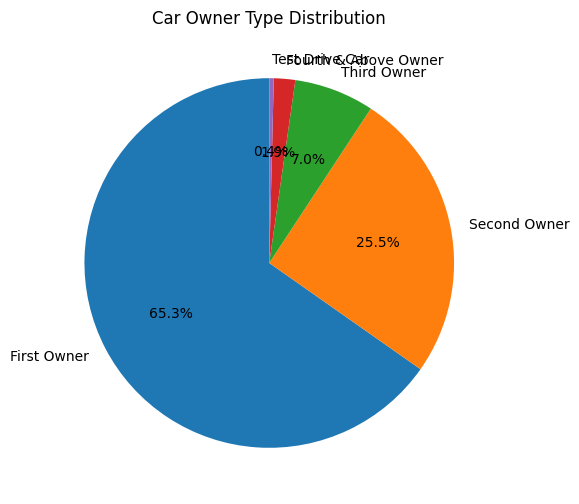

In [ ]:
owner_counts = df["owner"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(owner_counts, labels=owner_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Car Owner Type Distribution")
plt.show()

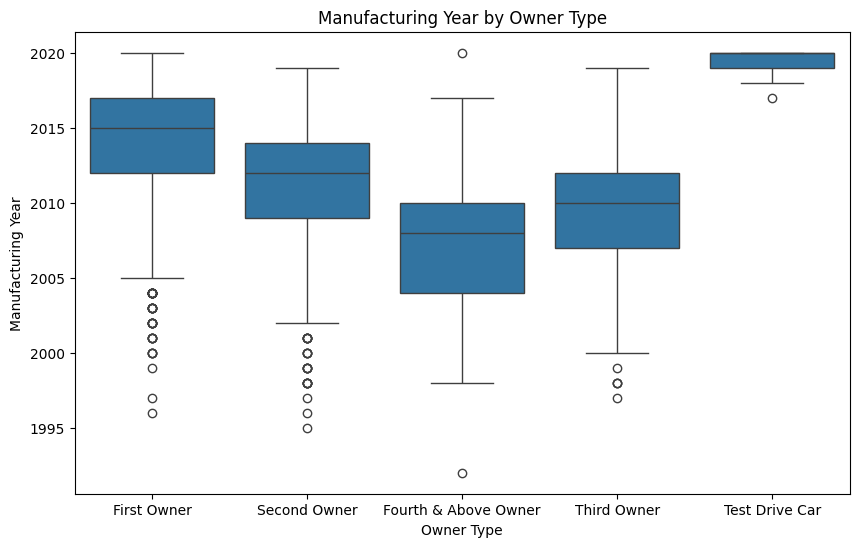

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x="owner", y="year", data=df)
plt.title("Manufacturing Year by Owner Type")
plt.xlabel("Owner Type")
plt.ylabel("Manufacturing Year")
plt.show()